In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme('poster')


In [41]:
df = pd.DataFrame({
    "mes": ["Janeiro", "Dezembro", "Novembro"],
    "faturamento": [18_683.63, 18_815.3, 18_421.67],
    "imposto_bom": [683.75, 692.25, 680.32],
})[::-1]


df["imposto_ruim"] = df["imposto_bom"] * 1.2


df

,mes,faturamento,imposto_bom,imposto_ruim
2,Novembro,18421.67,680.32,816.384
1,Dezembro,18815.30,692.25,830.700
0,Janeiro,18683.63,683.75,820.500


<Axes: title={'center': 'Imposto Pago'}, xlabel='Mês'>

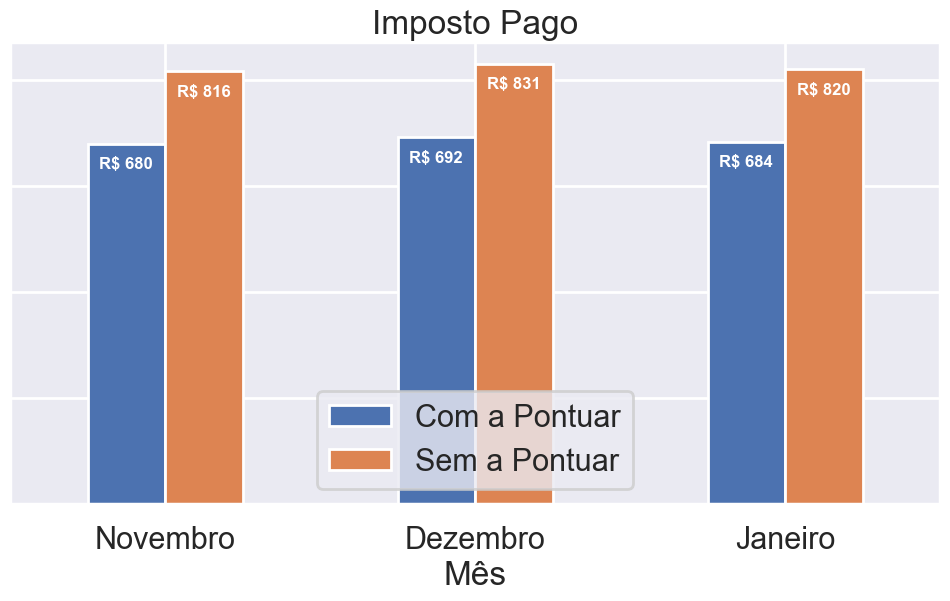

In [73]:
ax = df.plot.bar(x='mes', y=["imposto_bom", "imposto_ruim"], rot=0, xlabel='Mês', figsize=(12, 6), title='Imposto Pago')
plt.gcf().set_dpi(100)
for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.0f", padding=-20, color='white', fontsize=12, weight='bold')
    ax.set_yticklabels(())
ax.legend([ "Com a Pontuar", "Sem a Pontuar"], loc='lower center')
display(ax)

In [58]:
from typing import Literal

Anexo = Literal["I", "II", "III", "IV", "V"]

# Tabelas do Simples Nacional (Limites, Alíquota Nom\inal, Parcela a Deduzir)
TABELAS_ANEXOS = {
    "III": [
        (180000, 0.06, 0),
        (360000, 0.112, 9360),
        (720000, 0.135, 17640),
        (1800000, 0.16, 35640),
        (3600000, 0.21, 125640),
        (4800000, 0.33, 648000),
    ],
    "V": [
        (180000, 0.155, 0),
        (360000, 0.18, 4500),
        (720000, 0.195, 9900),
        (1800000, 0.205, 17100),
        (3600000, 0.23, 62100),
        (4800000, 0.305, 540000),
    ],
}

# Tabela IRRF 2024/2025 (Simplificada para o exemplo)
TABELA_IRRF = [
    (2259.20, 0.0, 0.0),
    (2826.65, 0.075, 169.44),
    (3751.05, 0.15, 381.44),
    (4664.68, 0.225, 662.77),
    (float('inf'), 0.275, 896.00)
]

TETO_INSS = 7786.02 

# --- FUNÇÕES DE CÁLCULO ---

def calcular_irrf(base_calculo: float) -> float:
    for limite, aliquota, deducao in TABELA_IRRF:
        if base_calculo <= limite:
            return max(0, (base_calculo * aliquota) - deducao)
    return (base_calculo * 0.275) - 896.00

def calcular_inss_socio(prolabore: float) -> float:
    # Simplificado: 11% sobre o prolabore limitado ao teto
    base = min(prolabore, TETO_INSS)
    return base * 0.11

def calcular_simples(faturamento: float, rbt12: float, anexo: Anexo) -> float:
    tabela = TABELAS_ANEXOS[anexo]
    aliquota_efetiva = 0.0
    for limite, aliquota, deducao in tabela:
        if rbt12 <= limite:
            aliquota_efetiva = (rbt12 * aliquota - deducao) / rbt12
            break
    return faturamento * aliquota_efetiva

def simular_cenario(
    faturamento_mensal: float,
    prolabore: float,
    anexo_base: Anexo,
    usa_fator_r: bool,
    custos_operacionais: float = 0
):
    rbt12 = faturamento_mensal * 12
    fator_r = prolabore / faturamento_mensal if faturamento_mensal > 0 else 0
    
    # Lógica Fator R: Se >= 28%, sai do V e vai pro III
    anexo_final = anexo_base
    if usa_fator_r:
        anexo_final = "III" if fator_r >= 0.28 else "V"
        
    # Imposto Simples
    das = calcular_simples(faturamento_mensal, rbt12, anexo_final)
    
    # Encargos sobre Pró-labore
    inss_socio = calcular_inss_socio(prolabore)
    # No Anexo IV, a empresa paga +20% de CPP sobre a folha
    cpp_patronal = (prolabore * 0.20) if anexo_final == "IV" else 0
    
    irrf_socio = calcular_irrf(prolabore - inss_socio)
    
    # Resultado Líquido
    total_impostos = das + cpp_patronal + inss_socio + irrf_socio
    lucro_distribuido = faturamento_mensal - total_impostos - prolabore - custos_operacionais
    renda_total_socio = prolabore - inss_socio - irrf_socio + max(0, lucro_distribuido)
    
    return {
        "prolabore": prolabore,
        "fator_r": fator_r,
        "anexo": anexo_final,
        "das": das,
        "inss_total": inss_socio + cpp_patronal,
        "irrf": irrf_socio,
        "renda_liquida_socio": renda_total_socio,
        "imposto_total": total_impostos
    }

In [64]:
simular_cenario(18000, 5100, "III", usa_fator_r=True)

{'prolabore': 5100,
 'fator_r': 0.2833333333333333,
 'anexo': 'III',
 'das': 1236.0,
 'inss_total': 561.0,
 'irrf': 358.505,
 'renda_liquida_socio': 14924.989999999998,
 'imposto_total': 2155.505}

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- REPARTIÇÃO OFICIAL (Percentuais aproximados das fatias do DAS para Serviços) ---
# Nota: No mundo real, esses % mudam levemente em cada uma das 6 faixas.
REPARTICAO = {
    "III": {"IRPJ": 0.04, "CSLL": 0.035, "CPP": 0.434, "ISS": 0.335, "PIS_COFINS": 0.156},
    "V":   {"IRPJ": 0.25, "CSLL": 0.15,  "CPP": 0.288, "ISS": 0.14,  "PIS_COFINS": 0.172}
}

TABELAS = {
    "III": [(180000, 0.06, 0), (360000, 0.112, 9360), (720000, 0.135, 17640), 
            (1800000, 0.16, 35640), (3600000, 0.21, 125640), (4800000, 0.33, 648000)],
    "V":   [(180000, 0.155, 0), (360000, 0.18, 4500), (720000, 0.195, 9900), 
            (1800000, 0.205, 17100), (3600000, 0.23, 62100), (4800000, 0.305, 540000)],
}

class SimuladorFatorR:
    def __init__(self, faturamento_mensal, rbt12_acumulado, folha12_acumulada):
        self.fat_mes = faturamento_mensal
        self.rbt12 = rbt12_acumulado
        self.folha12 = folha12_acumulada

    def calcular_imposto(self, prolabore_mes):
        # 1. Cálculo do Fator R (Folha 12 meses / Faturamento 12 meses)
        # Incluímos o pró-labore atual e o faturamento atual na conta
        fator_r = (self.folha12 + prolabore_mes) / (self.rbt12 + self.fat_mes)
        anexo = "III" if fator_r >= 0.28 else "V"
        
        # 2. Alíquota Efetiva
        tabela = TABELAS[anexo]
        aliq_efetiva = 0
        for limite, nominal, deducao in tabela:
            if (self.rbt12 + self.fat_mes) <= limite:
                aliq_efetiva = ((self.rbt12 + self.fat_mes) * nominal - deducao) / (self.rbt12 + self.fat_mes)
                break
        
        das_total = self.fat_mes * aliq_efetiva
        
        # 3. Repartição dos Tributos (A "Pizza" do Simples)
        rep = REPARTICAO[anexo]
        detalhe_das = {
            "IRPJ": das_total * rep["IRPJ"],
            "CSLL": das_total * rep["CSLL"],
            "INSS_Patronal_CPP": das_total * rep["CPP"],
            "ISS": das_total * rep["ISS"],
            "Outros_PIS_COFINS": das_total * rep["PIS_COFINS"]
        }
        
        # 4. Tributação na Pessoa Física (Sócio)
        inss_socio = min(prolabore_mes, 7786.02) * 0.11 # Teto INSS 2024/25
        # Cálculo simplificado de IRRF (apenas para o exemplo)
        irrf_socio = max(0, (prolabore_mes - inss_socio) * 0.15 - 381) 
        
        return {
            "anexo": anexo,
            "fator_r": fator_r,
            "das_total": das_total,
            "detalhe_das": detalhe_das,
            "inss_socio": inss_socio,
            "irrf_socio": irrf_socio,
            "custo_total": das_total + inss_socio + irrf_socio,
            "lucro_disponivel": self.fat_mes - (das_total + inss_socio + irrf_socio) - prolabore_mes
        }

    def otimizar(self):
        # Testa pró-labore de 1 salário mínimo até 40% do faturamento
        prolabores = np.linspace(1412, self.fat_mes * 0.4, 50)
        res_lista = [self.calcular_imposto(p) for p in prolabores]
        
        # Criar DataFrame para análise
        df = pd.DataFrame(res_lista)
        df['prolabore'] = prolabores
        
        # O melhor cenário é onde o (Lucro Disponível + Pró-labore Líquido) é maior
        df['renda_real_socio'] = df['lucro_disponivel'] + (df['prolabore'] - df['inss_socio'] - df['irrf_socio'])
        
        melhor = df.loc[df['renda_real_socio'].idxmax()]
        return melhor, df

# --- TESTE COM DADOS REAIS ---
# Empresa de TI com faturamento estável
sim = SimuladorFatorR(faturamento_mensal=18000, rbt12_acumulado=233405, folha12_acumulada=65905)
melhor_cenario, dados_completos = sim.otimizar()

print(f"--- RESULTADO DA OTIMIZAÇÃO ---")
print(f"Anexo Ideal: {melhor_cenario['anexo']} (Fator R: {melhor_cenario['fator_r']:.2%})")
print(f"Pró-labore sugerido: R$ {melhor_cenario['prolabore']:.2f}")
print(f"Total DAS: R$ {melhor_cenario['das_total']:.2f}")
print(f"Sendo INSS (CPP) dentro do DAS: R$ {melhor_cenario['detalhe_das']['INSS_Patronal_CPP']:.2f}")
print(f"Sendo IRPJ/CSLL: R$ {melhor_cenario['detalhe_das']['IRPJ'] + melhor_cenario['detalhe_das']['CSLL']:.2f}")

--- RESULTADO DA OTIMIZAÇÃO ---
Anexo Ideal: III (Fator R: 28.04%)
Pró-labore sugerido: R$ 4601.31
Total DAS: R$ 1345.85
Sendo INSS (CPP) dentro do DAS: R$ 584.10
Sendo IRPJ/CSLL: R$ 100.94


In [68]:
dados_completos

,anexo,fator_r,das_total,detalhe_das,inss_socio,irrf_socio,custo_total,lucro_disponivel,prolabore,renda_real_socio
0,V,0.267763,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",155.320000,0.000000,3073.130704,13514.869296,1412.000000,14771.549296
1,V,0.268233,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",168.313469,0.000000,3086.124173,13383.753378,1530.122449,14745.562357
2,V,0.268703,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",181.306939,0.000000,3099.117643,13252.637459,1648.244898,14719.575419
3,V,0.269173,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",194.300408,0.000000,3112.111112,13121.521541,1766.367347,14693.588480
4,V,0.269643,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",207.293878,0.000000,3125.104581,12990.405623,1884.489796,14667.601541
5,V,0.270112,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",220.287347,0.000000,3138.098051,12859.289704,2002.612245,14641.614602
6,V,0.270582,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",233.280816,0.000000,3151.091520,12728.173786,2120.734694,14615.627664
7,V,0.271052,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",246.274286,0.000000,3164.084990,12597.057868,2238.857143,14589.640725
8,V,0.271522,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",259.267755,0.000000,3177.078459,12465.941949,2356.979592,14563.653786
9,V,0.271992,2917.810704,"{'IRPJ': 729.4526759610986, 'CSLL': 437.671605...",272.261224,0.000000,3190.071928,12334.826031,2475.102041,14537.666847


anexo                                                             III
fator_r                                                      0.280449
das_total                                                 1345.846264
detalhe_das         {'IRPJ': 53.833850559853616, 'CSLL': 47.104619...
inss_socio                                                 506.143673
irrf_socio                                                 233.274367
custo_total                                               2085.264305
lucro_disponivel                                         11313.429573
prolabore                                                 4601.306122
renda_real_socio                                         15175.317654
Name: 27, dtype: object